# FLUX Image-to-Image Depth 🗒️🖼️

⚠️ **Remember to copy this notebook in your Drive and rename.**

🤗 This notebook uses [Hugging Face Diffusers](https://huggingface.co/docs/diffusers/en/index) to create pipelines for tasks such as image generation.

*Workflows for IAAC MaCDA GenAI  (Apr - Jun 2026) taught by [James McBennett](https://www.linkedin.com/in/mcbennett/) and [Aymeric Brouez](https://www.linkedin.com/in/aymeric-brouez/)*

*With special thanks to past faculty [Nono Martínez Alonso](https://youtube.com/NonoMartinezAlonso).*

***Workflow requires A100 runtime**


### Mount Drive

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Hugging Face Token

In [ ]:
# Sign up at Hugging Face and create a "Read" access token (not the default "Fine-Grained" token).
# Click the 🔑 "Secrets" icon in the left sidebar.
# Enable Notebook Access, Set the Name to "HF_TOKEN", Paste your token as the Value

from google.colab import userdata
hf_token = userdata.get("HF_TOKEN")

## Setup

In [ ]:
%cd /content
!rm -rf iaac_genai
!git clone https://github.com/jamesmcbennett/iaac_genai
%cd /content/iaac_genai/

/content
Cloning into 'creative-image-generation'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 137 (delta 68), reused 104 (delta 39), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 33.36 KiB | 1.33 MiB/s, done.
Resolving deltas: 100% (68/68), done.
/content/creative-image-generation


In [ ]:
import sys
sys.path.append('/content/iaac_genai')

In [ ]:
!pip install -q -r requirements.txt --quiet > /dev/null 2>&1

In [ ]:
from config import Config
from utils import set_image_path, save_image, save_yml, save_svg
import torch

from diffusers.utils import load_image
from transformers import pipeline
from PIL import Image
import numpy as np

## Output Directory

In [ ]:
Config.OUTPUT_DIR = '/content/drive/MyDrive/iaac_genai/outputs'

## Load Image

In [ ]:
# See options below on loading an image from Google drive or from an online link
#input_image = load_image("/content/drive/MyDrive/input/sample_image.png")
input_image = load_image("https://static.designboom.com/weblog/images/images_2/lauren/hangzhou%20waves/hw02.jpg")

resolution = 1024

#Square
w, h = input_image.size

min_dim = min(w, h)
crop_dim = min_dim #largest square
#crop_dim = 512

left = (w - crop_dim) // 2
top = (h - crop_dim) // 2
right = left + crop_dim
bottom = top + crop_dim
input_image = input_image.crop((left, top, right, bottom))

#Resize
max_dim = resolution
input_image = input_image.resize((max_dim, max_dim), Image.LANCZOS)

input_image_np = np.array(input_image)
input_image_np

array([[[232, 250, 254],
        [232, 250, 254],
        [232, 250, 254],
        ...,
        [217, 246, 254],
        [217, 246, 254],
        [217, 246, 254]],

       [[232, 250, 254],
        [232, 250, 254],
        [232, 250, 254],
        ...,
        [217, 246, 254],
        [217, 246, 254],
        [217, 246, 254]],

       [[232, 250, 254],
        [232, 250, 254],
        [232, 250, 254],
        ...,
        [217, 246, 254],
        [217, 246, 254],
        [217, 246, 254]],

       ...,

       [[173, 188, 195],
        [173, 188, 195],
        [172, 189, 196],
        ...,
        [123, 142, 149],
        [122, 141, 148],
        [122, 141, 148]],

       [[173, 188, 195],
        [174, 188, 195],
        [173, 190, 197],
        ...,
        [124, 143, 150],
        [123, 142, 149],
        [123, 142, 149]],

       [[174, 189, 196],
        [174, 189, 196],
        [174, 192, 198],
        ...,
        [124, 143, 150],
        [123, 142, 149],
        [123, 142, 149]]

## Depth

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


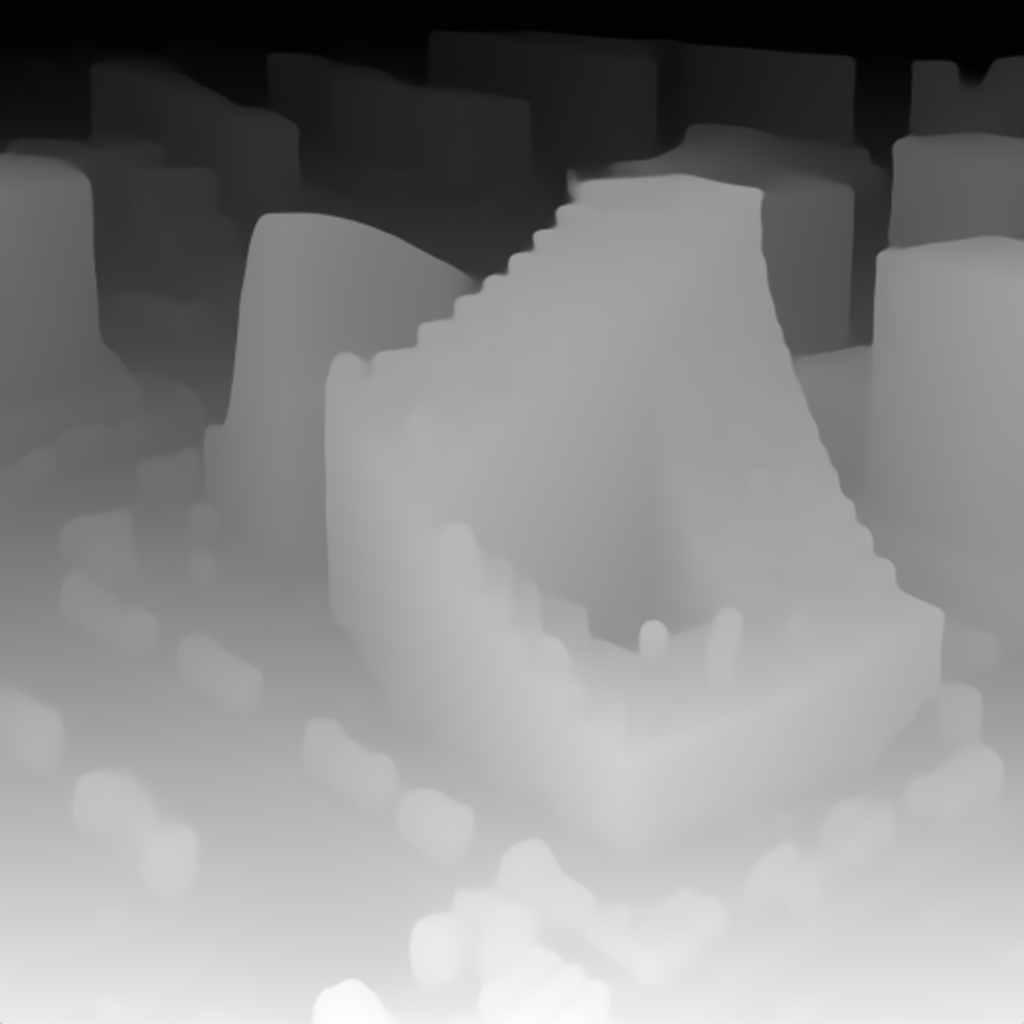

In [ ]:
#depth_estimator = pipeline('depth-estimation', model="Intel/dpt-large") #smaller lower filesize alternative
depth_estimator = pipeline('depth-estimation', model="LiheYoung/depth-anything-large-hf", token=hf_token)

depth_image = depth_estimator(input_image)['depth']
depth_image_np = np.array(depth_image)
depth_image_np = depth_image_np[:, :, None]
depth_image_np = np.concatenate([depth_image_np, depth_image_np, depth_image_np], axis=2)
depth_image_np = Image.fromarray(depth_image_np)

# download an image
depth_image_np

## Load pipeline

Load a pipeline with Hugging Face Diffusers.

In [ ]:
# Create pipeline (2 min load on A100)
from diffusers import FluxControlNetPipeline, FluxControlNetModel

base_model = 'black-forest-labs/FLUX.1-dev'
controlnet_model_union = 'Shakker-Labs/FLUX.1-dev-ControlNet-Union-Pro-2.0'
controlnet = FluxControlNetModel.from_pretrained(controlnet_model_union, torch_dtype=torch.bfloat16)
pipe = FluxControlNetPipeline.from_pretrained(base_model, controlnet=controlnet, torch_dtype=torch.bfloat16)
pipe.to("cuda")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/4.28G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


FluxControlNetPipeline {
  "_class_name": "FluxControlNetPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "black-forest-labs/FLUX.1-dev",
  "controlnet": [
    "diffusers",
    "FluxControlNetModel"
  ],
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5TokenizerFast"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

## Config

You can override parameters here.

In [ ]:
Config.PROMPT = 'A photorealistic wooden lattice building in a city, a swimming pool inside the courtyard block, with natural lighting and intricate structure.'
Config.SEED = 7797676568
Config.STEPS = 50

Config.AUTHOR = 'James'
Config.ALGO_TYPE = 'Image to Image'
Config.ALGO_NAME = 'Flux.1 Dev Depth'

Config.check()

Config OK.


## Generate

In [ ]:
# Generate
controlnet_conditioning_scale=0.7
control_guidance_end=0.8
guidance_scale=3.5

generator = torch.Generator(Config.TORCH_DEVICE).manual_seed(Config.SEED)
image = pipe(Config.PROMPT, control_image=depth_image_np, height=resolution, width=resolution, controlnet_conditioning_scale=controlnet_conditioning_scale, control_guidance_end=control_guidance_end, num_inference_steps=Config.STEPS, guidance_scale=guidance_scale, max_sequence_length=256, generator=generator).images[0]
set_image_path()
display(image)

## Save

Save the pipeline and config metadata, generated image, and the parameters image.

In [ ]:
# Save image
save_image(image)

In [ ]:
# Save yml metadata
save_yml(pipe)

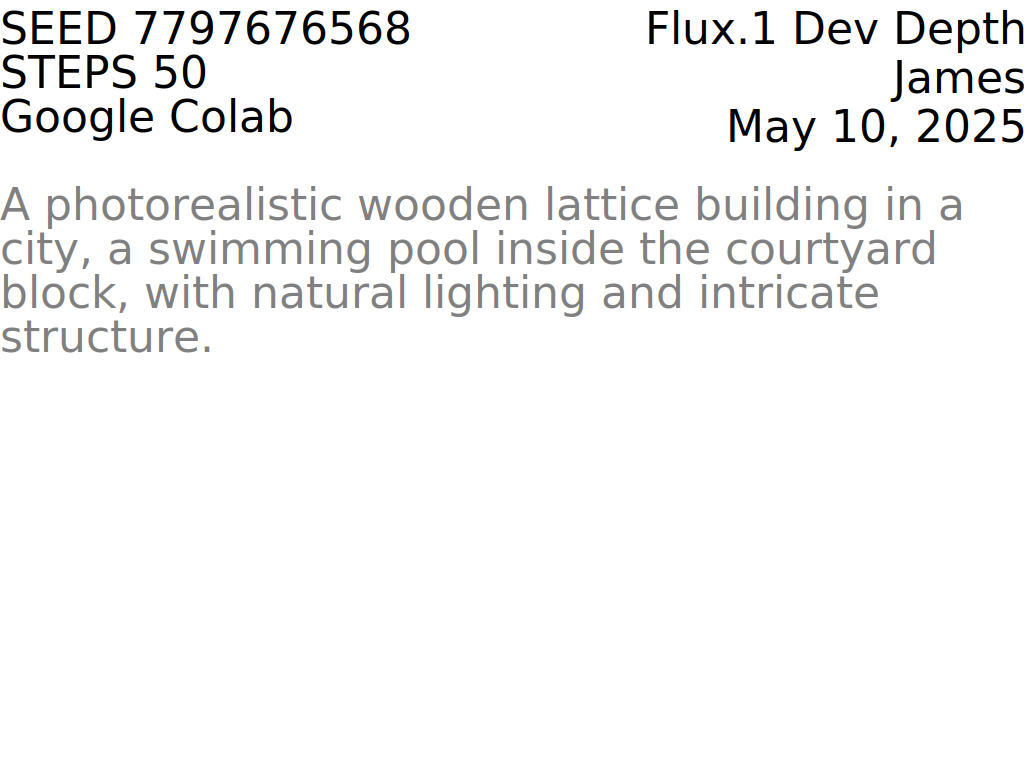

'/content/drive/MyDrive/outputs/Image-to-Image_Flux.1-Dev-Depth/250510_174653_A_photorealistic_wooden_lattice_building_in_a_city,_a_swimming_pool_in_steps050.svg'

In [ ]:
# Save svg parameters image
save_svg({
    'SEED': Config.SEED,
    'STEPS': Config.STEPS,
    'Google Colab': '',
})

## Disconnect

In [ ]:
from google.colab import runtime
runtime.unassign()